In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

with open(
    "../data/processed/data_summary.json"
) as f:
    summary = json.load(f)

df = pd.read_parquet(
    "../data/processed/perten_raw.parquet"
)

spectral_columns = summary["spectral_columns"]

wavelengths = np.array([
    float(x)
    for x in spectral_columns
])

X = df[
    spectral_columns
].to_numpy(float)

protein = df[
    summary["protein_column"]
].to_numpy()

moisture = df[
    summary["moisture_column"]
].to_numpy()

### Spectral Noise

In [4]:
from scipy.signal import savgol_filter

X_derivative = savgol_filter(
    X,
    window_length=11,
    polyorder=2,
    deriv=1,
    axis=1
)

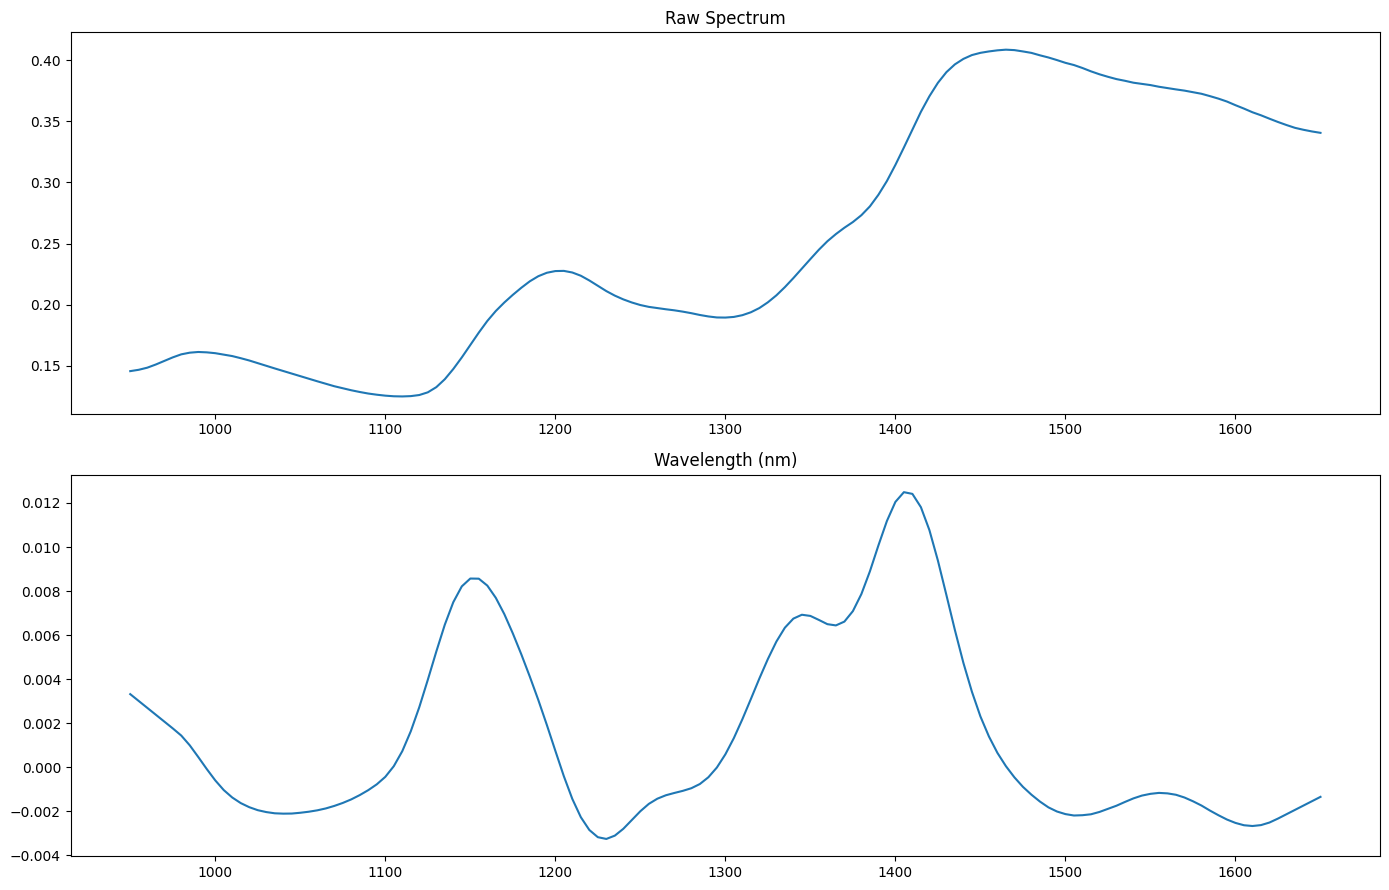

In [5]:
fig, axes = plt.subplots(2,1,figsize=(14,9))

axes[0].plot(wavelengths, X[0])
axes[0].set_title("Raw Spectrum")

axes[1].plot(wavelengths, X_derivative[0])
axes[1].set_title("First Derivative")

axes[1].set_title("Wavelength (nm)")

plt.tight_layout()
plt.show()

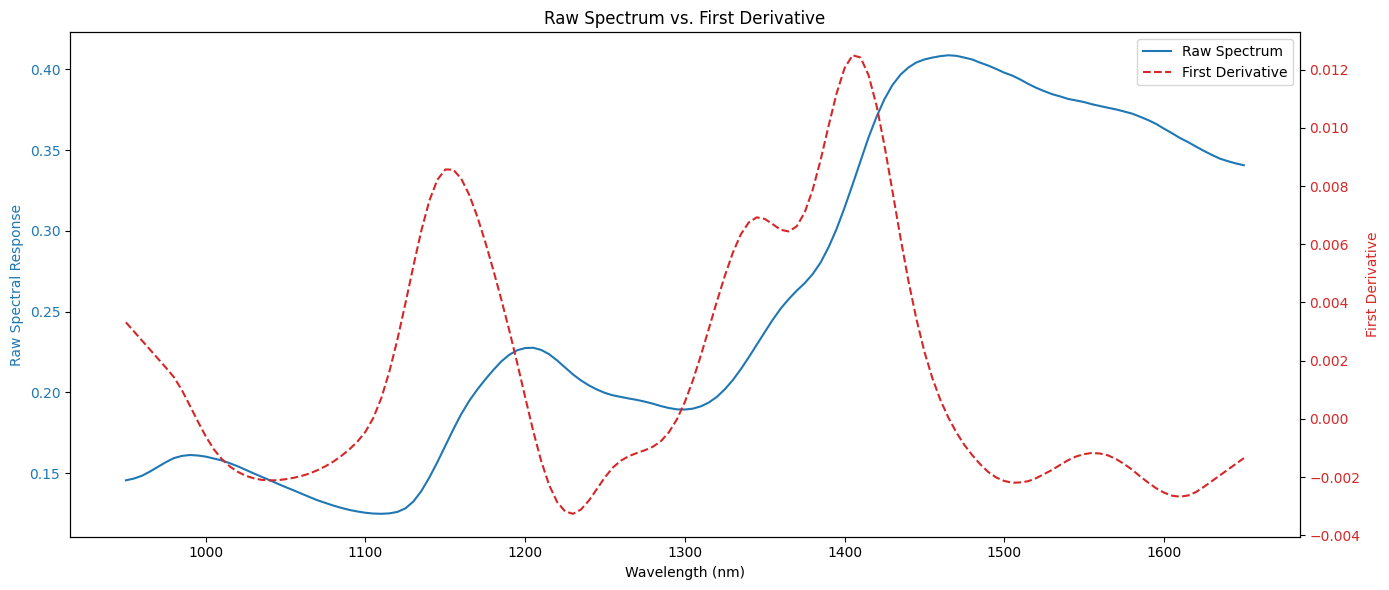

In [6]:
fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot raw spectrum on the primary (left) y-axis
line1 = ax1.plot(wavelengths, X[0], color="tab:blue", label="Raw Spectrum")
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel("Raw Spectral Response", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Create a secondary (right) y-axis for the derivative
ax2 = ax1.twinx()
line2 = ax2.plot(
    wavelengths,
    X_derivative[0],
    color="tab:red",
    linestyle="--",
    label="First Derivative",
)
ax2.set_ylabel("First Derivative", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Combine legends into a single box
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper right")

plt.title("Raw Spectrum vs. First Derivative")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_scaled = StandardScaler().fit_transform(X)

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

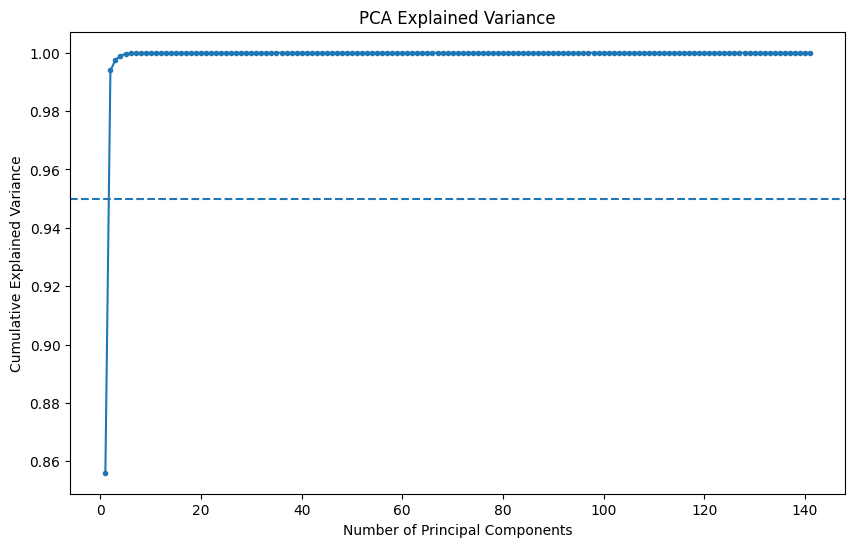

In [15]:
plt.figure(figsize=(10,6))

plt.plot(
    range(1,len(cumulative_variance)+1),
    cumulative_variance,
    marker="."
)

plt.axhline(0.95, linestyle="--")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.show()

How many latent dimensions describe the dominant spectral variation?
Mainly first 3 to 4 is best

### PCA Loading Analysis

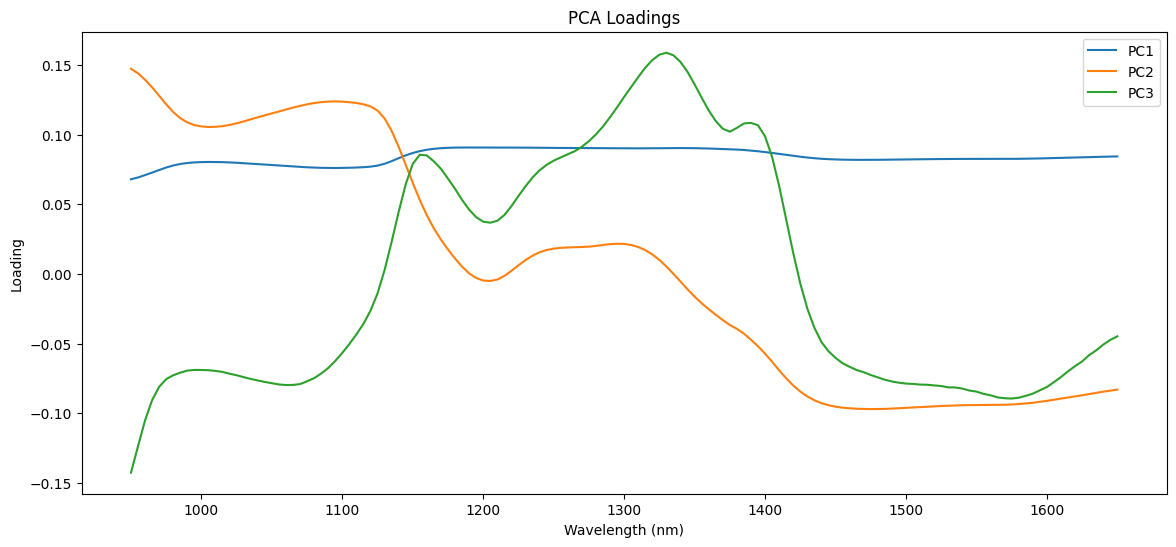

In [17]:
plt.figure(figsize=(14,6))

for i in range(3):

    plt.plot(wavelengths, pca.components_[i], label=f"PC{i+1}")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Loading")
plt.title("PCA Loadings")
plt.legend()

plt.show()